In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os 

os.chdir('../..')

BASE_DIR = os.getcwd()

alley_path = BASE_DIR + '/data/raw/properties/alley_houses.csv'
apart_path = BASE_DIR + '/data/raw/properties/apartment.csv'
land_path = BASE_DIR + '/data/raw/properties/land.csv'
street_path = BASE_DIR + '/data/raw/properties/street_house.csv'

# Alley houses

In [3]:
df_alley = pd.read_csv(alley_path)

df_alley.head()

,Ma_BDS,Dia_chi,Tong_gia (trieu),Tien_m2 (trieu/m2),Loại hình,Chiều ngang,Chiều dài,Hướng cửa chính,Số phòng ngủ,Số phòng tắm,Số tầng,Diện tích đất công nhận,Diện tích sử dụng,Đường trước nhà,Nội thất,Giấy tờ pháp lý
0,SA27D5,"60/15/16A số 2, P.Hiệp Bình Phước, TP.Thủ Đức,...",5600000.0,76.19,Nhà hẻm,4m,21.24m,Tây Bắc,2.0,2.0,2.0,73.50m²,NaN,4m,Cơ bản,NaN
1,21JNPZ,"217 Võ Thị Sáu, Đông Hòa, Dĩ An, TP.HCM",6950000.0,96.52,Nhà hẻm,4m,NaN,NaN,4.0,4.0,2.0,NaN,72m²,NaN,NaN,NaN
2,PV5Q5G,"222/4 Nguyễn Thái Sơn, P.4, Q.Gò Vấp, TP.HCM",7120000.0,78.65,Nhà hẻm,NaN,NaN,Tây Bắc,NaN,NaN,NaN,NaN,90.60m²,NaN,NaN,NaN
3,6Q2EG8,"Nguyễn Bình Ấp 2, Xã Phú Xuân, H.Nhà Bè, TP.HCM",3650000.0,82.95,Nhà hẻm,3.61m,13.78m,Đông Bắc,2.0,1.0,1.0,44m²,33.30m²,4m,Cơ bản,NaN
4,3DW1EQ,"77/4 Quốc lộ 1A, P.Linh Xuân, TP.Thủ Đức, TP.HCM",4900000.0,41.88,Nhà hẻm,NaN,NaN,Đông Nam,NaN,NaN,NaN,NaN,117m²,NaN,NaN,NaN


In [4]:
df_alley.columns

Index(['Ma_BDS', 'Dia_chi', 'Tong_gia (trieu)', 'Tien_m2 (trieu/m2)',
       'Loại hình', 'Chiều ngang', 'Chiều dài', 'Hướng cửa chính',
       'Số phòng ngủ', 'Số phòng tắm', 'Số tầng', 'Diện tích đất công nhận',
       'Diện tích sử dụng', 'Đường trước nhà', 'Nội thất', 'Giấy tờ pháp lý'],
      dtype='str')

In [5]:
df_alley = df_alley.drop(columns=['Chiều ngang', 'Chiều dài', 'Hướng cửa chính', 'Diện tích đất công nhận',
       'Diện tích sử dụng', 'Đường trước nhà', 'Nội thất', 'Giấy tờ pháp lý'])

In [6]:
df_alley.columns

Index(['Ma_BDS', 'Dia_chi', 'Tong_gia (trieu)', 'Tien_m2 (trieu/m2)',
       'Loại hình', 'Số phòng ngủ', 'Số phòng tắm', 'Số tầng'],
      dtype='str')

In [7]:
df_alley.rename(columns={
    'Ma_BDS': 'id',
    'Dia_chi': 'address',
    'Tong_gia (trieu)': 'total_price_millions',
    'Tien_m2 (trieu/m2)': 'price_per_m2_millions',
    'Loại hình': 'property_type',
    'Số phòng ngủ': 'bedrooms',
    'Số phòng tắm': 'bathrooms',
    'Số tầng': 'floors',
}, inplace=True)

In [8]:
df_alley['area'] = np.round(df_alley['total_price_millions'] /  df_alley['price_per_m2_millions'], 2)

In [9]:
df_alley.isna().sum()

id                        0
address                   0
total_price_millions      0
price_per_m2_millions     0
property_type             0
bedrooms                 50
bathrooms                50
floors                   50
area                      0
dtype: int64

In [10]:
df_alley.dtypes

id                           str
address                      str
total_price_millions     float64
price_per_m2_millions    float64
property_type                str
bedrooms                 float64
bathrooms                float64
floors                   float64
area                     float64
dtype: object

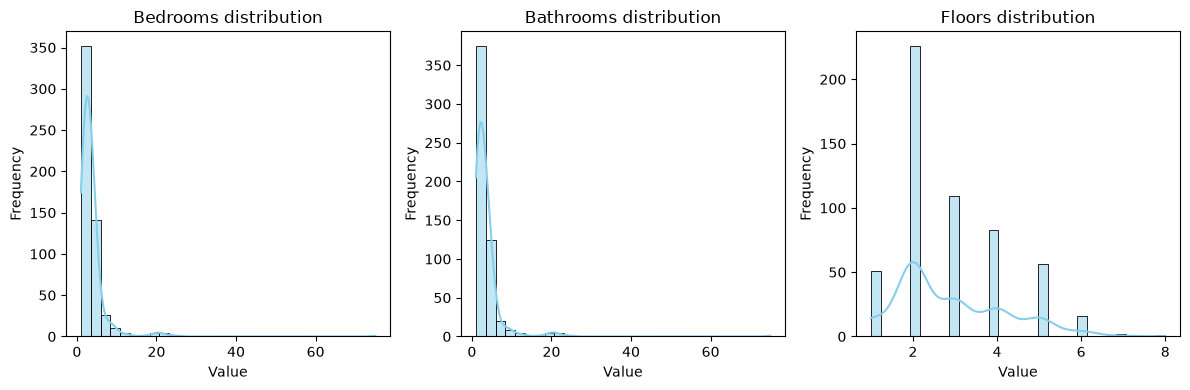

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, i in zip(axes, ('bedrooms', 'bathrooms', 'floors')):
    sns.histplot(df_alley[i], kde=True, bins=30, color='skyblue', ax=ax)
    
    ax.set_title(f'{i.capitalize()} distribution')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [12]:
df_alley[df_alley['bedrooms'] > 10]

,id,address,total_price_millions,price_per_m2_millions,property_type,bedrooms,bathrooms,floors,area
90,7KFYXA,"105/48 đường số 59, P.14, Q.Gò Vấp, TP.HCM",16800000.0,301.61,Nhà hẻm,19.0,20.0,6.0,55701.07
112,R2UN4J,"Lê Đức Thọ, P.17, Q.Gò Vấp, TP.HCM",35500000.0,215.41,Nhà hẻm,25.0,25.0,6.0,164802.01
135,K4RUMC,"70/28 Hà Thị Đát, P.Tân Quý, Q.Tân Phú, TP.HCM",18500000.0,154.16,Nhà hẻm,22.0,22.0,5.0,120005.19
162,3SDJ5Q,"428/6/13-15 An Dương Vương, P.16, Q.8, TP.HCM",13000000.0,180.30,Nhà hẻm,12.0,12.0,1.0,72102.05
184,ACGM9Y,"Vườn Lài, P.An Phú Đông, Q.12, TP.HCM",7500000.0,118.85,Nhà hẻm,11.0,11.0,6.0,63104.75
213,37APFQ,"111/2 Vườn Lài, P.Phú Thọ Hòa, Q.Tân Phú, TP.HCM",19000000.0,120.78,Nhà hẻm,17.0,17.0,6.0,157310.81
343,5HKJ47,"204/20 Nguyễn Oanh, P.17, Q.Gò Vấp, TP.HCM",25500000.0,242.62,Nhà hẻm,20.0,20.0,6.0,105102.63
349,JZZW20,"106C/121-123 Lạc Long Quân, P.3, Q.11, TP.HCM",25000000.0,311.72,Nhà hẻm,21.0,21.0,5.0,80200.18
361,2XV34Z,"207/64A Nguyễn Văn Đậu, P.11, Q.Bình Thạnh, TP...",28000000.0,202.02,Nhà hẻm,21.0,21.0,6.0,138600.14
430,RZ2PGJ,"656/6 Quang Trung, P.11, Q.Gò Vấp, TP.HCM",50000000.0,251.63,Nhà hẻm,75.0,75.0,8.0,198704.45


In [13]:
def fill_floor(df):
    med = round(df['floors'].median())
    
    missing_idx = df[df['floors'].isna()].index
    
    for idx in missing_idx:
        area = df.loc[idx, 'area']
        
        near = df[
            (df['area'] >= area - 5) & 
            (df['area'] <= area + 5)
        ]
        
        value = near['floors'].dropna()
        
        if not value.empty:
            df.at[idx, 'floors'] = round(value.mean())
        else:
            df.at[idx, 'floors'] = med
            
    return df

In [14]:
def fill_bed_bath(df, cols):

    for col in cols :
        med = df[col].median()
        
        missing = df[df[col].isna()]
        
        for idx, row in missing.iterrows():
            floor = df[df['floors'] == row['floors']]
            
            # Lọc tiếp theo diện tích +- 5m2
            lan_can = floor[
                (floor['area'] >= row['area'] - 5) & 
                (floor['area'] <= row['area'] + 5)
            ]
            
            value = lan_can[col].dropna()
            
            if not value.empty:
                df.at[idx, col] = value.mode().iloc[0]
            else:
                df.at[idx, col] = med
            
    return df



In [15]:
df_alley = fill_floor(df_alley)
df_alley = fill_bed_bath(df_alley, ('bedrooms', 'bathrooms'))
df_alley.isnull().sum()

id                       0
address                  0
total_price_millions     0
price_per_m2_millions    0
property_type            0
bedrooms                 0
bathrooms                0
floors                   0
area                     0
dtype: int64

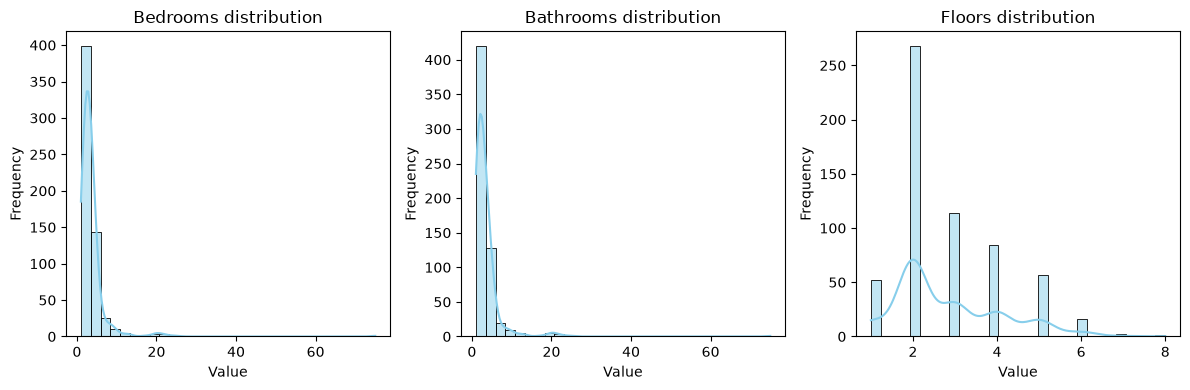

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, i in zip(axes, ('bedrooms', 'bathrooms', 'floors')):
    sns.histplot(df_alley[i], kde=True, bins=30, color='skyblue', ax=ax)
    
    ax.set_title(f'{i.capitalize()} distribution')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [17]:
df_alley['property_type'] = 'alley'
df_alley['property_type'] = df_alley['property_type'].astype('category')

In [18]:
df_alley.dtypes

id                            str
address                       str
total_price_millions      float64
price_per_m2_millions     float64
property_type            category
bedrooms                  float64
bathrooms                 float64
floors                    float64
area                      float64
dtype: object

# Apartment

In [19]:
df_apart = pd.read_csv(apart_path)

df_apart.head()

,Ma_BDS,Dia_chi,Tong_gia (trieu),Tien_m2 (trieu/m2),Loại hình,Địa chỉ chi tiết,Hướng ban công,Số phòng ngủ,Số phòng tắm,Diện tích tim tường,Diện tích sử dụng,Nội thất,Tên dự án tòa nhà,Tình trạng sử dụng
0,W22Y9R,"10 Võ Chí Công, P.Phước Long B, TP.Thủ Đức, TP...",4500000.0,90.00,Căn hộ chung cư,A10-21-09,Tây Bắc,1.0,1.0,50.0,45.0,Cơ bản,Imperia Sensa,Nhà trống
1,7DTU5A,"đường Phước Thiện, Long Bình, Q.9, TP.HCM",3500000.0,52.63,Căn hộ chung cư,"Căn hộ 2.19, Tầng 2, Tòa nhà S7.02",NaN,2.0,3.0,66.5,NaN,NaN,"Phân khu The Origami, Khu đô thị Vinhomes Gran...",NaN
2,6QZNQ8,"326/1 Đường Ung Văn Khiêm, P.25, Q.Bình Thạnh,...",5400000.0,72.19,Căn hộ chung cư,12.1 - 13,NaN,2.0,1.0,74.8,NaN,NaN,Chung cư Thế Kỷ 21,Nhà trống
3,UKMA4S,"137 Gò Dầu, P.Tân Quý, Q.Tân Phú, TP.HCM",2450000.0,30.62,Căn hộ chung cư,NaN,NaN,2.0,2.0,NaN,NaN,Cơ bản,NaN,NaN
4,JPC7G0,"Chung cư Hoàng Anh Gold Place, đường Lê Văn Lư...",4100000.0,36.93,Căn hộ chung cư,"Căn hộ số 3.1 tầng 3, Khu A2",NaN,3.0,2.0,111.0,111.0,NaN,Chung cư Hoàng Anh Gold Place,NaN


In [20]:
df_apart.columns

Index(['Ma_BDS', 'Dia_chi', 'Tong_gia (trieu)', 'Tien_m2 (trieu/m2)',
       'Loại hình', 'Địa chỉ chi tiết', 'Hướng ban công', 'Số phòng ngủ',
       'Số phòng tắm', 'Diện tích tim tường', 'Diện tích sử dụng', 'Nội thất',
       'Tên dự án tòa nhà', 'Tình trạng sử dụng'],
      dtype='str')

In [21]:
df_apart = df_apart.drop(columns=['Địa chỉ chi tiết', 'Hướng ban công','Diện tích tim tường', 'Diện tích sử dụng', 'Nội thất',
       'Tên dự án tòa nhà', 'Tình trạng sử dụng'])

In [22]:
df_apart.columns

Index(['Ma_BDS', 'Dia_chi', 'Tong_gia (trieu)', 'Tien_m2 (trieu/m2)',
       'Loại hình', 'Số phòng ngủ', 'Số phòng tắm'],
      dtype='str')

In [23]:
df_apart.rename(columns={
    'Ma_BDS': 'id',
    'Dia_chi': 'address',
    'Tong_gia (trieu)': 'total_price_millions',
    'Tien_m2 (trieu/m2)': 'price_per_m2_millions',
    'Loại hình': 'property_type',
    'Số phòng ngủ': 'bedrooms',
    'Số phòng tắm': 'bathrooms',
}, inplace=True)

In [24]:
df_apart['floors'] = 1 

In [25]:
df_apart.isna().sum()

id                       0
address                  0
total_price_millions     0
price_per_m2_millions    0
property_type            0
bedrooms                 1
bathrooms                1
floors                   0
dtype: int64

In [26]:
df_apart['bedrooms'] = df_apart['bedrooms'].fillna(df_apart['bedrooms'].median())
df_apart['bathrooms'] = df_apart['bathrooms'].fillna(df_apart['bathrooms'].median())

In [27]:
df_apart.isna().sum()

id                       0
address                  0
total_price_millions     0
price_per_m2_millions    0
property_type            0
bedrooms                 0
bathrooms                0
floors                   0
dtype: int64

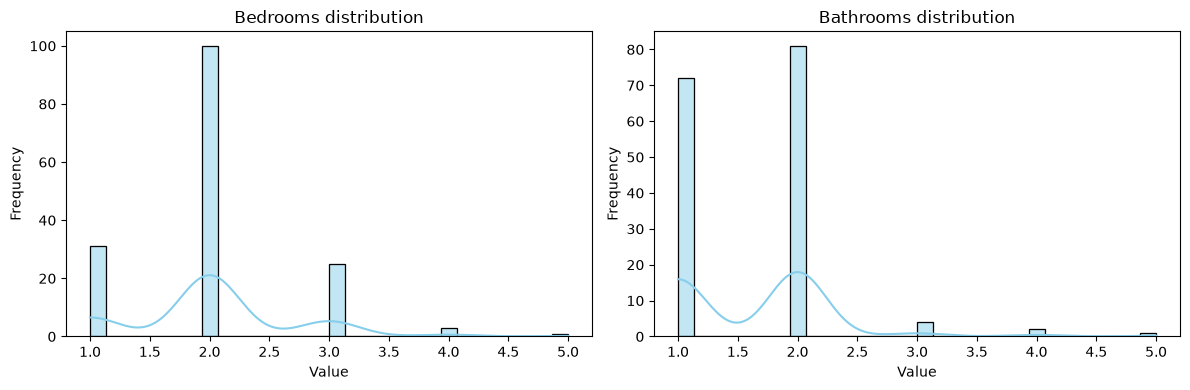

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, i in zip(axes, ('bedrooms', 'bathrooms')):
    sns.histplot(df_apart[i], kde=True, bins=30, color='skyblue', ax=ax)
    
    ax.set_title(f'{i.capitalize()} distribution')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [29]:
df_apart['property_type'] = 'apartment'
df_apart['property_type'] = df_apart['property_type'].astype('category')

# Land

In [30]:
df_land = pd.read_csv(land_path)

df_land.head()

,Ma_BDS,Dia_chi,Tong_gia (trieu),Tien_m2 (trieu/m2),Loại hình,Chiều ngang,Chiều dài,Hướng cửa chính
0,RGVA8J,"Thửa 616 - tờ 19, đường Đặng Như Mai, Thạnh Mỹ...",58000000.0,200.55,Đất,15m,20m,Đông Nam
1,4PBVHF,"49/3a Đỗ Tấn Phong, Tân Đông Hiệp, Dĩ An, TP.HCM",2950000.0,45.38,Đất,5m,NaN,NaN
2,3Y32PQ,"44 Quốc lộ 1K, P.Đông Hòa, TP.Dĩ An, TP.HCM",5950000.0,39.66,Đất,7.5m,22m,NaN
3,WZ8H4R,"254/4A Phạm Văn Chí, P.Bình Tiên, Q.6, TP.HCM",4700000.0,94.37,Đất,NaN,NaN,Tây Bắc
4,KJN5TC,"160 số 1, P.Long Trường, TP.Thủ Đức, TP.HCM",6700000.0,49.92,Đất,NaN,NaN,Bắc


In [31]:
df_land.columns

Index(['Ma_BDS', 'Dia_chi', 'Tong_gia (trieu)', 'Tien_m2 (trieu/m2)',
       'Loại hình', 'Chiều ngang', 'Chiều dài', 'Hướng cửa chính'],
      dtype='str')

In [32]:
df_land = df_land.drop(columns=['Chiều ngang', 'Chiều dài', 'Hướng cửa chính'])

In [33]:
df_land.columns

Index(['Ma_BDS', 'Dia_chi', 'Tong_gia (trieu)', 'Tien_m2 (trieu/m2)',
       'Loại hình'],
      dtype='str')

In [34]:
df_land['bedrooms'] = np.nan
df_land['bathrooms'] = np.nan
df_land['floats'] = np.nan

In [35]:
df_land.rename(columns={
    'Ma_BDS': 'id',
    'Dia_chi': 'address',
    'Tong_gia (trieu)': 'total_price_millions',
    'Tien_m2 (trieu/m2)': 'price_per_m2_millions',
    'Loại hình': 'property_type'
}, inplace=True)

In [36]:
df_land.isna().sum()

id                          0
address                     0
total_price_millions        0
price_per_m2_millions       0
property_type               0
bedrooms                 3174
bathrooms                3174
floats                   3174
dtype: int64

In [37]:
df_land['property_type'] = 'land'
df_land['property_type'] = df_land['property_type'].astype('category')

# Street house

In [38]:
df_street = pd.read_csv(street_path)

df_street.head()

,Ma_BDS,Dia_chi,Tong_gia (trieu),Tien_m2 (trieu/m2),Loại hình,Chiều ngang,Chiều dài,Hướng cửa chính,Số phòng ngủ,Số phòng tắm,Số tầng,Diện tích đất công nhận,Diện tích sử dụng,Đường trước nhà,Nội thất,Giấy tờ pháp lý
0,GXWFS2,"Tam Long, TP.HCM, TP.HCM",3600000.0,28.66,Nhà mặt tiền,5m,25m,Đông Bắc,2.0,2.0,3.0,125.60m²,NaN,NaN,NaN,NaN
1,DF5Y0H,"Khu dân cư 13A Intresco, xã Bình Hưng, TP. HCM...",18200000.0,130.00,Nhà mặt tiền,7m,20m,NaN,1.0,1.0,2.0,140m²,140m²,20m,Bàn giao thô,NaN
2,DR9BKH,"42/9 Tân Hiệp 4, Xã Tân Hiệp, H.Hóc Môn, TP.HCM",7200000.0,40.00,Nhà mặt tiền,9m,20m,Đông Nam,1.0,2.0,2.0,180m²,180m²,10m,Đầy đủ,NaN
3,YBEX4D,"193 Cô Giang, P.Cô Giang, Q.1, TP.HCM",25000000.0,596.65,Nhà mặt tiền,3.57m,19.22m,Tây Bắc,5.0,5.0,5.0,41.90m²,121.20m²,12m,NaN,NaN
4,6AUU58,"33 Ngô Văn Sở, Dĩ An, Dĩ An, TP.HCM",8800000.0,96.70,Nhà mặt tiền,4.4m,NaN,NaN,4.0,5.0,3.0,NaN,91m²,NaN,NaN,NaN


In [39]:
df_street.columns

Index(['Ma_BDS', 'Dia_chi', 'Tong_gia (trieu)', 'Tien_m2 (trieu/m2)',
       'Loại hình', 'Chiều ngang', 'Chiều dài', 'Hướng cửa chính',
       'Số phòng ngủ', 'Số phòng tắm', 'Số tầng', 'Diện tích đất công nhận',
       'Diện tích sử dụng', 'Đường trước nhà', 'Nội thất', 'Giấy tờ pháp lý'],
      dtype='str')

In [40]:
df_street = df_street.drop(columns=['Chiều ngang', 'Chiều dài', 'Hướng cửa chính','Diện tích đất công nhận', 'Diện tích sử dụng', 'Đường trước nhà', 'Nội thất', 'Giấy tờ pháp lý'])

In [41]:
df_street.columns

Index(['Ma_BDS', 'Dia_chi', 'Tong_gia (trieu)', 'Tien_m2 (trieu/m2)',
       'Loại hình', 'Số phòng ngủ', 'Số phòng tắm', 'Số tầng'],
      dtype='str')

In [42]:
df_street.rename(columns={
    'Ma_BDS': 'id',
    'Dia_chi': 'address',
    'Tong_gia (trieu)': 'total_price_millions',
    'Tien_m2 (trieu/m2)': 'price_per_m2_millions',
    'Loại hình': 'property_type',
    'Số phòng ngủ': 'bedrooms',
    'Số phòng tắm': 'bathrooms',
    'Số tầng': 'floors',
}, inplace=True)

In [43]:
df_street.isna().sum()

id                       0
address                  0
total_price_millions     0
price_per_m2_millions    0
property_type            0
bedrooms                 2
bathrooms                3
floors                   3
dtype: int64

In [44]:
df_street['area'] = np.round(df_street['total_price_millions'] /  df_street['price_per_m2_millions'], 2)

for col in ('bedrooms', 'bathrooms', 'floors'):
    df_street[col] = pd.to_numeric(df_street[col], errors='coerce')

    median_val = df_street[col].median()
    df_street[col] = df_street[col].fillna(median_val)
    


In [45]:
df_street.isna().sum()

id                       0
address                  0
total_price_millions     0
price_per_m2_millions    0
property_type            0
bedrooms                 0
bathrooms                0
floors                   0
area                     0
dtype: int64

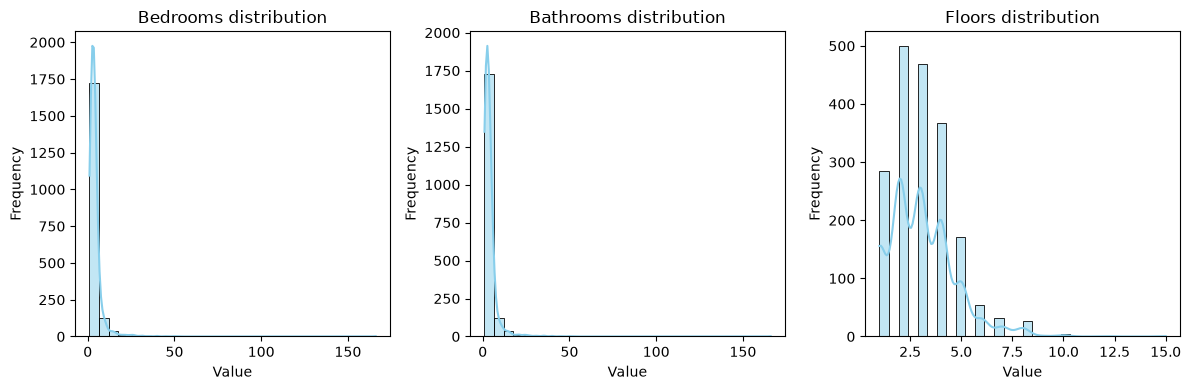

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, i in zip(axes, ('bedrooms', 'bathrooms', 'floors')):
    sns.histplot(df_street[i], kde=True, bins=30, color='skyblue', ax=ax)
    
    ax.set_title(f'{i.capitalize()} distribution')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [47]:
df_street['property_type'] = 'street'
df_street['property_type'] = df_street['property_type'].astype('category')

In [48]:
df_street.dtypes

id                            str
address                       str
total_price_millions      float64
price_per_m2_millions     float64
property_type            category
bedrooms                  float64
bathrooms                 float64
floors                    float64
area                      float64
dtype: object

In [49]:
df_alley.columns

Index(['id', 'address', 'total_price_millions', 'price_per_m2_millions',
       'property_type', 'bedrooms', 'bathrooms', 'floors', 'area'],
      dtype='str')

In [50]:
df_street.columns

Index(['id', 'address', 'total_price_millions', 'price_per_m2_millions',
       'property_type', 'bedrooms', 'bathrooms', 'floors', 'area'],
      dtype='str')

In [51]:
df_land['area'] = np.round(df_land['total_price_millions'] /  df_land['price_per_m2_millions'], 2)
df_land.columns

Index(['id', 'address', 'total_price_millions', 'price_per_m2_millions',
       'property_type', 'bedrooms', 'bathrooms', 'floats', 'area'],
      dtype='str')

In [52]:
df_apart['area'] = np.round(df_apart['total_price_millions'] /  df_apart['price_per_m2_millions'], 2)
df_apart.columns

Index(['id', 'address', 'total_price_millions', 'price_per_m2_millions',
       'property_type', 'bedrooms', 'bathrooms', 'floors', 'area'],
      dtype='str')

In [53]:
df_apart.shape[0] + df_land.shape[0] + df_street.shape[0] + df_alley.shape[0]

5842

In [54]:
df_merged = pd.concat(
    [df_alley, df_street, df_land, df_apart], 
    ignore_index=True
)

print(f"Tổng số bản ghi sau khi nối: {len(df_merged)}")
df_merged.head()

Tổng số bản ghi sau khi nối: 5842


,id,address,total_price_millions,price_per_m2_millions,property_type,bedrooms,bathrooms,floors,area,floats
0,SA27D5,"60/15/16A số 2, P.Hiệp Bình Phước, TP.Thủ Đức,...",5600000.0,76.19,alley,2.0,2.0,2.0,73500.46,NaN
1,21JNPZ,"217 Võ Thị Sáu, Đông Hòa, Dĩ An, TP.HCM",6950000.0,96.52,alley,4.0,4.0,2.0,72005.80,NaN
2,PV5Q5G,"222/4 Nguyễn Thái Sơn, P.4, Q.Gò Vấp, TP.HCM",7120000.0,78.65,alley,3.0,2.0,2.0,90527.65,NaN
3,6Q2EG8,"Nguyễn Bình Ấp 2, Xã Phú Xuân, H.Nhà Bè, TP.HCM",3650000.0,82.95,alley,2.0,1.0,1.0,44002.41,NaN
4,3DW1EQ,"77/4 Quốc lộ 1A, P.Linh Xuân, TP.Thủ Đức, TP.HCM",4900000.0,41.88,alley,3.0,2.0,2.0,117000.96,NaN


In [56]:
df_merged.to_csv(BASE_DIR + '/data/process/merge_properties_data.csv', index=False)